In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("data/BitCoin_Mining.csv")
df = df.drop(columns=["timestamp", "mem_total", "latency_ms"])

In [33]:
df = df.dropna()
print(df.shape)
print(df.describe())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.dropna())
# pd.DataFrame(scaled_data, columns=df.columns.dropna()).head(3)

(24957, 9)
           mem_used   power_watts      gpu_util   temperature     fan_speed  \
count  24957.000000  24957.000000  24957.000000  24957.000000  24957.000000   
mean       3.960139     30.493423     99.013704     56.431262  32765.687062   
std        0.192408      8.577073      9.703038      3.039341    207.415158   
min        0.160000      2.830000      0.000000     50.000000      0.000000   
25%        3.970000     26.940000    100.000000     54.000000  32767.000000   
50%        3.970000     27.120000    100.000000     56.000000  32767.000000   
75%        3.970000     27.470000    100.000000     58.000000  32767.000000   
max        3.970000     50.430000    100.000000     67.000000  32767.000000   

         core_clock  memory_clock    pcie_rx_MB   pcie_tx_MB  
count  24957.000000  24957.000000  24957.000000  24957.00000  
mean    1772.709460   5954.746965      1.657050      0.02929  
std      132.401724    500.983538      0.759343      0.16886  
min      300.000000    40

              mem_used  power_watts  gpu_util  temperature  fan_speed  \
mem_used          1.00         0.16      0.52         0.07      -0.00   
power_watts       0.16         1.00      0.27         0.76      -0.01   
gpu_util          0.52         0.27      1.00         0.14      -0.00   
temperature       0.07         0.76      0.14         1.00      -0.02   
fan_speed        -0.00        -0.01     -0.00        -0.02       1.00   
core_clock        0.53         0.28      0.93         0.14       0.00   
memory_clock      0.52         0.28      0.92         0.15      -0.00   
pcie_rx_MB        0.11        -0.86      0.20        -0.67       0.01   
pcie_tx_MB        0.01        -0.07      0.02        -0.01       0.00   

              core_clock  memory_clock  pcie_rx_MB  pcie_tx_MB  
mem_used            0.53          0.52        0.11        0.01  
power_watts         0.28          0.28       -0.86       -0.07  
gpu_util            0.93          0.92        0.20        0.02  
temperatu

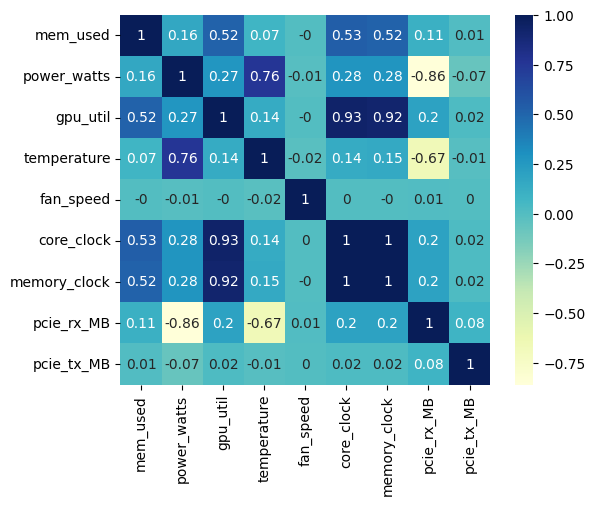

In [28]:
co_mtx = round(df.corr(numeric_only=True), 2)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, square=True)

# Display heatmap
plt.show()

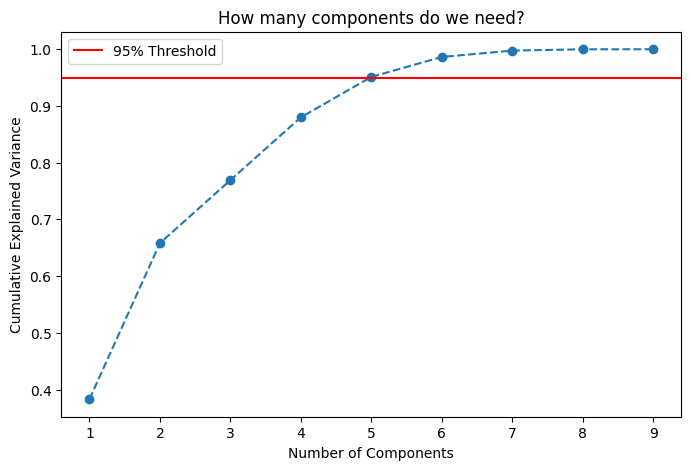

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA without a limit first to see all components
pca_full = PCA().fit(scaled_data)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('How many components do we need?')
plt.legend()
plt.show()

[[ 1.60374733e+00 -6.63533746e+00 -1.51947779e+02 -4.28788820e+01
  -3.33756308e-02]
 [ 1.14301544e+00 -3.96593176e+00  3.76410020e-02  1.34302983e-01
   1.82850733e-02]
 [ 1.14477621e+00 -3.96973913e+00  3.77071072e-02  1.34389004e-01
   1.81305558e-02]
 ...
 [-2.45947255e+01 -4.64785884e+00 -8.84697947e-02  3.79838167e-01
  -1.14748083e+01]
 [-2.45967797e+01 -4.64341691e+00 -8.85469174e-02  3.79737809e-01
  -1.14746280e+01]
 [-2.46582658e+01 -4.46665324e+00 -8.19955402e-02  3.51024895e-01
  -1.14620937e+01]]


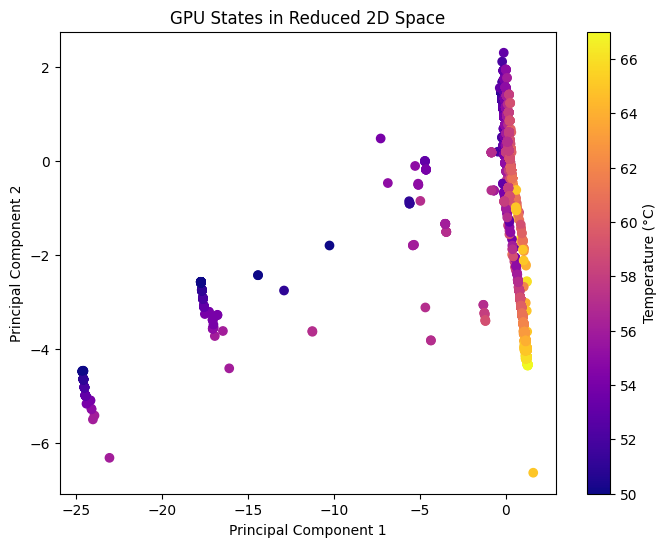

In [41]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)
print(pca_result)


plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['temperature'], cmap='plasma')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GPU States in Reduced 2D Space')
plt.show()

# Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

In [47]:
X = pca_result
y = df['temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 12)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [57]:
predictions = model.predict(X_test_poly)
print(f"MAE: {mean_absolute_error(y_test, predictions):.2f}°C")
print(f"R² Score: {r2_score(y_test, predictions):.2f}")

MAE: 0.43°C
R² Score: 0.95


In [ ]:
pcr = LinearRegression()
pcr_model.fit(X_train_poly, y_train)
predictions2 = pcr_model.predict(X_test_poly)